<a href="https://colab.research.google.com/github/sandyy221/244107020029_PemMes/blob/main/Tugas_DBcosine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Setup Awal

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

1. Data Understanding

1.1 Load Dataset

In [ ]:
df = pd.read_csv('burnout_dataset1.csv')

df.head()

print(f'Jumlah data  : {df.shape[0]}')
print(f'Jumlah kolom : {df.shape[1]}')

Jumlah data  : 50000
Jumlah kolom : 40


1.2 Data Preview

In [ ]:
print("5 Baris Pertama Dataset:")
display(df.head())

print("\nNama Semua Kolom:")
print(df.columns.tolist())

5 Baris Pertama Dataset:


,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk
0,1,58.0,Male,United States,Marketing Manager,Diploma,Employed,2786.0,67,Hybrid,...,No,Yes,Average,6.0,19.0,2,82,Critical,Practice Mindfulness,High
1,2,24.0,Female,Pakistan,Freelancer,Bachelor,Student,8027.0,44,Hybrid,...,Yes,No,Good,4.0,27.0,22,64,Critical,Reduce Workload,Moderate
2,3,59.0,Male,Malaysia,Accountant,PhD,Employed,3177.0,60,No,...,Yes,No,Average,4.0,51.0,17,50,Needs Attention,Increase Physical Activity,Moderate
3,4,65.0,Other,Mexico,Chef,Master,Self-Employed,4093.0,25,Yes,...,No,Yes,Good,7.0,83.0,14,16,Healthy,Maintain Healthy Routine,Low
4,5,64.0,Other,Japan,Farmer,Diploma,Student,NaN,52,No,...,Yes,No,Poor,9.0,61.0,4,26,Healthy,Reduce Workload,Low



Nama Semua Kolom:
['Person_ID', 'Age', 'Gender', 'Country', 'Occupation', 'Education_Level', 'Employment_Status', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Sleep_Quality', 'Stress_Level', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Exercise_Frequency', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score', 'Mental_Health_Status', 'AI_Wellness_Recommendation', 'Burnout_Risk']


1.3 Tipe data dan Missing Values

In [ ]:
print('Tipe Data:')
print(df.dtypes)

print('\nJumlah Missing Value:')
missing = df.isnull().sum()

missing[missing > 0]

Tipe Data:
Person_ID                          int64
Age                              float64
Gender                            object
Country                           object
Occupation                        object
Education_Level                   object
Employment_Status                 object
Monthly_Income_USD               float64
Work_Hours_Per_Week                int64
Remote_Work                       object
Job_Satisfaction                 float64
Work_Life_Balance                float64
Sleep_Hours                      float64
Sleep_Quality                     object
Stress_Level                      object
Anxiety_Score                    float64
Depression_Score                 float64
Mood_Score                       float64
Emotional_Stability                int64
Physical_Activity_Hours          float64
Exercise_Frequency                object
Meditation_Minutes               float64
Screen_Time_Hours                float64
Social_Media_Hours               float64
Gamin

,0
Age,250
Monthly_Income_USD,1450
Job_Satisfaction,500
Work_Life_Balance,650
Sleep_Hours,950
Anxiety_Score,800
Depression_Score,850
Mood_Score,900
Physical_Activity_Hours,1100
Meditation_Minutes,1200


1.4 Identifikasi Kolom yang Digunakan

In [ ]:
# Kolom numerik asli
numeric_columns = df.select_dtypes(include='number').columns

# Menghapus identifier
numeric_columns = numeric_columns.drop(
    ['Person_ID'],
    errors='ignore'
)

# Kolom kategorikal yang akan di-encoding
categorical_columns = [
    'Remote_Work',
    'Sleep_Quality',
    'Stress_Level',
    'Exercise_Frequency',
    'Alcohol_Consumption',
    'Smoking',
    'Healthy_Diet',
    'Chronic_Stress',
    'Family_History_Mental_Illness',
    'Therapy_Attendance',
    'Support_System',
    'Mental_Health_Status'
]

print('Kolom Numerik:')
print(numeric_columns.tolist())

print('\nKolom Kategorikal yang akan di-encoding:')
print(categorical_columns)

Kolom Numerik:
['Age', 'Monthly_Income_USD', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Work_Life_Balance', 'Sleep_Hours', 'Anxiety_Score', 'Depression_Score', 'Mood_Score', 'Emotional_Stability', 'Physical_Activity_Hours', 'Meditation_Minutes', 'Screen_Time_Hours', 'Social_Media_Hours', 'Gaming_Hours', 'Coffee_Cups_Per_Day', 'Life_Satisfaction', 'Productivity_Score', 'Absenteeism_Days', 'Burnout_Score']

Kolom Kategorikal yang akan di-encoding:
['Remote_Work', 'Sleep_Quality', 'Stress_Level', 'Exercise_Frequency', 'Alcohol_Consumption', 'Smoking', 'Healthy_Diet', 'Chronic_Stress', 'Family_History_Mental_Illness', 'Therapy_Attendance', 'Support_System', 'Mental_Health_Status']


1.5 Statistik Deskriptif

In [ ]:
df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,49750.0,41.448181,13.871634,18.0,29.0,41.0,53.0,65.0
Monthly_Income_USD,48550.0,6251.281524,3319.661435,500.0,3381.0,6231.0,9134.0,12000.0
Work_Hours_Per_Week,50000.0,44.946160,14.729024,20.0,32.0,45.0,58.0,70.0
Job_Satisfaction,49500.0,5.499051,2.866621,1.0,3.0,6.0,8.0,10.0
Work_Life_Balance,49350.0,5.504397,2.867492,1.0,3.0,6.0,8.0,10.0
Sleep_Hours,49050.0,6.997445,1.728766,4.0,5.5,7.0,8.5,10.0
Anxiety_Score,49200.0,40.449045,26.004291,0.0,19.0,39.0,59.0,100.0
Depression_Score,49150.0,40.601160,26.308933,0.0,19.0,39.0,60.0,100.0
Mood_Score,49100.0,59.622994,25.783486,0.0,41.0,61.0,80.0,100.0
Emotional_Stability,50000.0,59.382100,26.090946,0.0,40.0,60.0,81.0,100.0


1.6 Visualisasi Distribusi Data

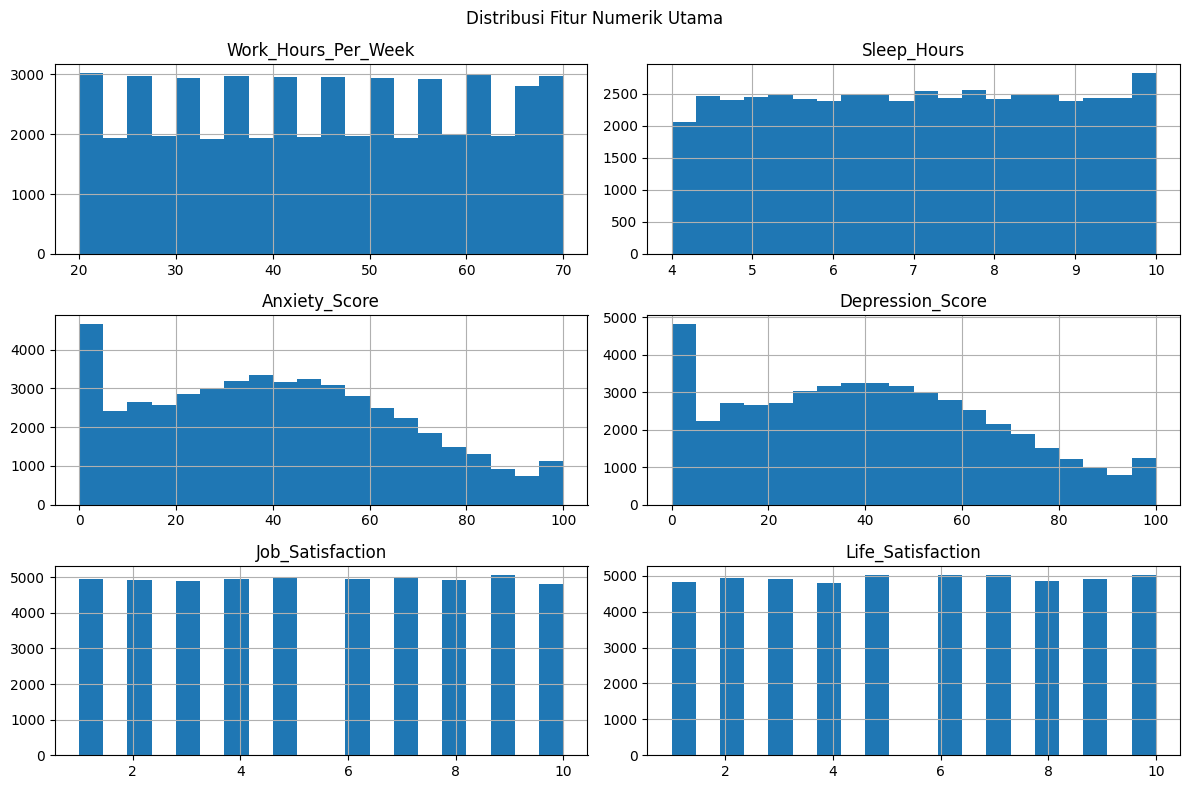

In [ ]:
selected_features = [
    'Work_Hours_Per_Week',
    'Sleep_Hours',
    'Anxiety_Score',
    'Depression_Score',
    'Job_Satisfaction',
    'Life_Satisfaction'
]

df[selected_features].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle('Distribusi Fitur Numerik Utama')
plt.tight_layout()
plt.show()

1.7 Visualisasi Deteksi Outlier

In [ ]:
numeric_columns = df.select_dtypes(include='number').columns

numeric_columns = numeric_columns.drop(
    ['person_id', 'Person_ID'],
    errors='ignore'
)

numeric_data = df[numeric_columns]

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (numeric_data < lower_bound) |
    (numeric_data > upper_bound)
)

In [ ]:
outlier_summary = pd.DataFrame({
    'Jumlah Outlier': outlier_mask.sum(),
    'Persentase (%)': (
        outlier_mask.sum() / len(df) * 100
    ).round(2)
})

outlier_summary = outlier_summary.sort_values(
    'Jumlah Outlier',
    ascending=False
)

outlier_summary

,Jumlah Outlier,Persentase (%)
Age,0,0.0
Monthly_Income_USD,0,0.0
Work_Hours_Per_Week,0,0.0
Job_Satisfaction,0,0.0
Work_Life_Balance,0,0.0
Sleep_Hours,0,0.0
Anxiety_Score,0,0.0
Depression_Score,0,0.0
Mood_Score,0,0.0
Emotional_Stability,0,0.0


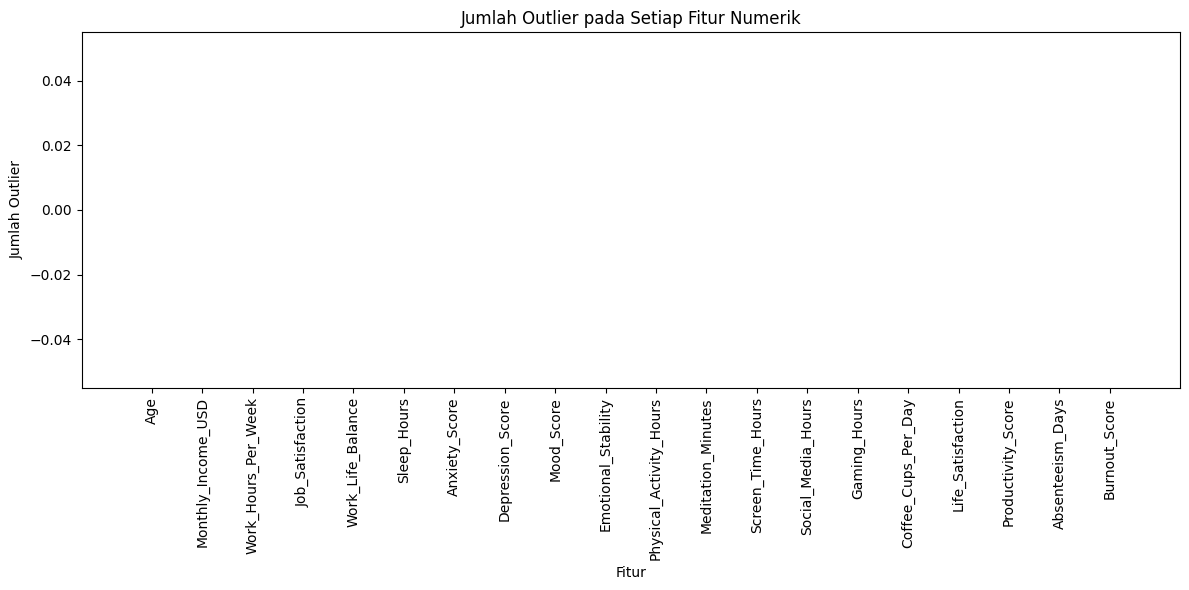

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    outlier_summary.index,
    outlier_summary['Jumlah Outlier']
)

plt.title('Jumlah Outlier pada Setiap Fitur Numerik')
plt.xlabel('Fitur')
plt.ylabel('Jumlah Outlier')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
print(outlier_summary)

                         Jumlah Outlier  Persentase (%)
Age                                   0             0.0
Monthly_Income_USD                    0             0.0
Work_Hours_Per_Week                   0             0.0
Job_Satisfaction                      0             0.0
Work_Life_Balance                     0             0.0
Sleep_Hours                           0             0.0
Anxiety_Score                         0             0.0
Depression_Score                      0             0.0
Mood_Score                            0             0.0
Emotional_Stability                   0             0.0
Physical_Activity_Hours               0             0.0
Meditation_Minutes                    0             0.0
Screen_Time_Hours                     0             0.0
Social_Media_Hours                    0             0.0
Gaming_Hours                          0             0.0
Coffee_Cups_Per_Day                   0             0.0
Life_Satisfaction                     0         

2.1 Seleksi Kolom

In [ ]:
selected_columns = list(numeric_columns) + categorical_columns

X = df[selected_columns].copy()

X.head()

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,58.0,2786.0,67,3.0,7.0,4.6,74.0,75.0,26.0,18,...,High,Weekly,Yes,Yes,No,Yes,No,Yes,Average,Critical
1,24.0,8027.0,44,5.0,8.0,4.7,58.0,80.0,29.0,37,...,Moderate,Weekly,Yes,Yes,Yes,No,Yes,No,Good,Critical
2,59.0,3177.0,60,8.0,7.0,6.3,54.0,55.0,44.0,48,...,Moderate,Daily,Yes,No,No,No,Yes,No,Average,Needs Attention
3,65.0,4093.0,25,2.0,9.0,7.1,12.0,11.0,88.0,80,...,Low,Weekly,Yes,No,No,No,No,Yes,Good,Healthy
4,64.0,NaN,52,1.0,4.0,9.1,25.0,48.0,67.0,76,...,Low,Never,Yes,No,No,No,Yes,No,Poor,Healthy


2.2 Encoding Data Kategorikal

In [ ]:
encoding_maps = {
    'Remote_Work': {
        'No': 0,
        'Hybrid': 1,
        'Yes': 2
    },

    'Sleep_Quality': {
        'Excellent': 0,
        'Good': 1,
        'Average': 2,
        'Poor': 3
    },

    'Stress_Level': {
        'Low': 0,
        'Moderate': 1,
        'High': 2
    },

    'Exercise_Frequency': {
        'Daily': 0,
        'Weekly': 1,
        'Rarely': 2,
        'Never': 3
    },

    'Alcohol_Consumption': {
        'No': 0,
        'Yes': 1
    },

    'Smoking': {
        'No': 0,
        'Yes': 1
    },

    'Healthy_Diet': {
        'No': 0,
        'Yes': 1
    },

    'Chronic_Stress': {
        'No': 0,
        'Yes': 1
    },

    'Family_History_Mental_Illness': {
        'No': 0,
        'Yes': 1
    },

    'Therapy_Attendance': {
        'No': 0,
        'Yes': 1
    },

    'Support_System': {
        'Good': 0,
        'Average': 1,
        'Poor': 2,
        'Excellent': 3
    },

    'Mental_Health_Status': {
        'Healthy': 0,
        'Needs Attention': 1,
        'Critical': 2
    }
}

for column, mapping in encoding_maps.items():
    X[column] = X[column].map(mapping)

X[categorical_columns].head()

,Remote_Work,Sleep_Quality,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1,3,2,1,1,1,0,1,0,1.0,1,2
1,1,3,1,1,1,1,1,0,1,0.0,0,2
2,0,2,1,0,1,0,0,0,1,0.0,1,1
3,2,1,0,1,1,0,0,0,0,1.0,0,0
4,0,0,0,3,1,0,0,0,1,0.0,2,0


2.3 Penanganan Missing Values

In [ ]:
print('Missing value sebelum preprocessing:')
print(X.isnull().sum())

X = X.fillna(X.median())

print(
    '\nJumlah missing value setelah preprocessing:',
    X.isnull().sum().sum()
)

Missing value sebelum preprocessing:
Age                               250
Monthly_Income_USD               1450
Work_Hours_Per_Week                 0
Job_Satisfaction                  500
Work_Life_Balance                 650
Sleep_Hours                       950
Anxiety_Score                     800
Depression_Score                  850
Mood_Score                        900
Emotional_Stability                 0
Physical_Activity_Hours          1100
Meditation_Minutes               1200
Screen_Time_Hours                 850
Social_Media_Hours                600
Gaming_Hours                      750
Coffee_Cups_Per_Day                 0
Life_Satisfaction                 700
Productivity_Score                950
Absenteeism_Days                    0
Burnout_Score                       0
Remote_Work                         0
Sleep_Quality                       0
Stress_Level                        0
Exercise_Frequency                  0
Alcohol_Consumption                 0
Smoking      

2.4 Penanganan Outlier

In [ ]:
# Karena tidak, tidak dilakukan

2.5 Standardisasi

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196378,-1.059170,1.497320,-0.877799,0.522638,-1.400203,1.301535,1.319769,-1.316899,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,-0.996685,2.53389,-0.996765,1.016577,-0.445191,1.633584
1,-1.260836,0.543024,-0.064238,-0.176698,0.873599,-1.341801,0.681279,1.511451,-1.199485,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,1.003326,-0.39465,1.003245,-0.983693,-1.341128,1.633584
2,1.268649,-0.939640,1.022063,0.874952,0.522638,-0.407356,0.526215,0.553042,-0.612419,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-0.445191,0.373764
3,1.702275,-0.659615,-1.354221,-1.228349,1.224560,0.059866,-1.101957,-1.133757,1.109642,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,-0.996685,-0.39465,-0.996765,1.016577,-1.341128,-0.886057
4,1.630004,-0.006020,0.478912,-1.578899,-0.530247,1.227922,-0.597999,0.284688,0.287749,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,0.450746,-0.886057
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,-0.393584,-0.828669,-0.132132,0.874952,0.171676,0.001464,0.642513,0.323024,-0.573281,-0.551235,...,0.411952,-0.455507,1.008436,-0.996327,1.003326,-0.39465,1.003245,-0.983693,-0.445191,0.373764
49996,1.124107,1.338771,-1.422115,-1.228349,0.171676,-1.575412,-1.334553,-1.555457,1.305331,1.556797,...,-1.014673,-1.351150,1.008436,1.003687,-0.996685,-0.39465,-0.996765,1.016577,1.346683,-0.886057
49997,-0.538126,-0.950034,0.750488,0.874952,-1.232169,0.351880,0.952641,1.434779,-1.042934,-1.011169,...,0.411952,1.335781,1.008436,-0.996327,1.003326,-0.39465,-0.996765,1.016577,0.450746,1.633584
49998,1.413191,-0.754995,-1.082646,-0.176698,0.522638,0.001464,-0.326637,-0.903739,0.561714,0.100338,...,-1.014673,1.335781,1.008436,1.003687,-0.996685,-0.39465,-0.996765,1.016577,0.450746,-0.886057


2.6 Data Bersih

In [ ]:
print('Dimensi data setelah preprocessing:', X.shape)
print('Jumlah missing value:', X.isnull().sum().sum())

X_scaled.head()

Dimensi data setelah preprocessing: (50000, 32)
Jumlah missing value: 0


,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,...,Stress_Level,Exercise_Frequency,Alcohol_Consumption,Smoking,Healthy_Diet,Chronic_Stress,Family_History_Mental_Illness,Therapy_Attendance,Support_System,Mental_Health_Status
0,1.196378,-1.059170,1.497320,-0.877799,0.522638,-1.400203,1.301535,1.319769,-1.316899,-1.586087,...,1.838578,-0.455507,1.008436,1.003687,-0.996685,2.53389,-0.996765,1.016577,-0.445191,1.633584
1,-1.260836,0.543024,-0.064238,-0.176698,0.873599,-1.341801,0.681279,1.511451,-1.199485,-0.857858,...,0.411952,-0.455507,1.008436,1.003687,1.003326,-0.39465,1.003245,-0.983693,-1.341128,1.633584
2,1.268649,-0.939640,1.022063,0.874952,0.522638,-0.407356,0.526215,0.553042,-0.612419,-0.436251,...,0.411952,-1.351150,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,-0.445191,0.373764
3,1.702275,-0.659615,-1.354221,-1.228349,1.224560,0.059866,-1.101957,-1.133757,1.109642,0.790240,...,-1.014673,-0.455507,1.008436,-0.996327,-0.996685,-0.39465,-0.996765,1.016577,-1.341128,-0.886057
4,1.630004,-0.006020,0.478912,-1.578899,-0.530247,1.227922,-0.597999,0.284688,0.287749,0.636928,...,-1.014673,1.335781,1.008436,-0.996327,-0.996685,-0.39465,1.003245,-0.983693,0.450746,-0.886057


3. Modeling

3.1 Penentuan Parameter eps

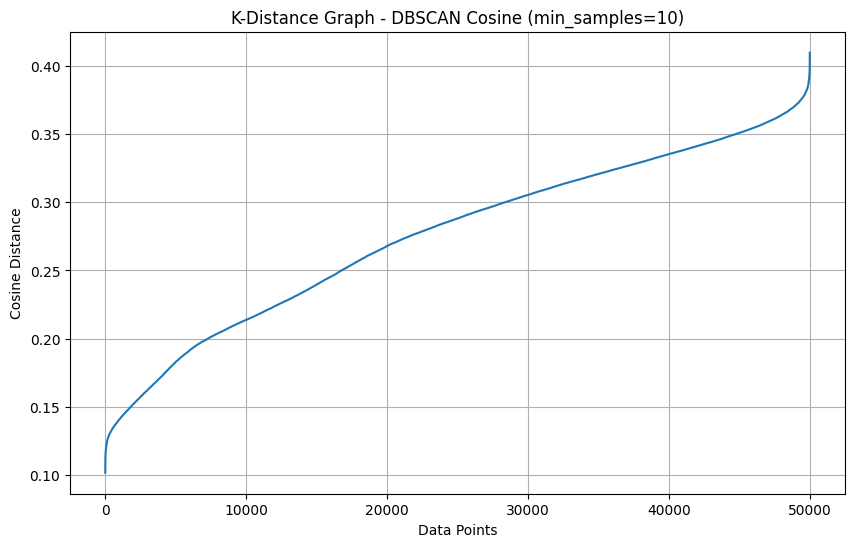

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Nilai min_samples awal
min_samples = 10

# Menggunakan cosine distance
neighbors = NearestNeighbors(
    n_neighbors=min_samples,
    metric='cosine'
)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(X_scaled)

k_distances = distances[:, -1]
k_distances = np.sort(k_distances)

plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.title(
    f'K-Distance Graph - DBSCAN Cosine (min_samples={min_samples})'
)
plt.xlabel('Data Points')
plt.ylabel('Cosine Distance')
plt.grid(True)

plt.show()

3.2 Eksperimen min_samples

In [ ]:
from sklearn.cluster import DBSCAN

# Nilai eps awal
eps = 0.3

# nilai min_samples yang akan diuji
min_samples_list = [5, 10, 15, 20]

experiment_results = []

for min_samples in min_samples_list:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric='cosine',
        n_jobs=-1
    )

    labels = dbscan.fit_predict(X_scaled)


    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    n_noise = np.sum(labels == -1)

    experiment_results.append({
        'min_samples': min_samples,
        'Jumlah Cluster': n_clusters,
        'Jumlah Noise': n_noise,
        'Persentase Noise (%)': round(
            n_noise / len(labels) * 100, 2
        )
    })

experiment_results = pd.DataFrame(experiment_results)

experiment_results

,min_samples,Jumlah Cluster,Jumlah Noise,Persentase Noise (%)
0,5,24,2885,5.77
1,10,12,8608,17.22
2,15,3,12783,25.57
3,20,2,15288,30.58


3.3 Training DBSCAN Manhattan

4. Evaluasi

In [ ]:
# Parameter final DBSCAN
eps_final = 0.3
min_samples_final = 10

# Membuat model DBSCAN dengan Cosine Distance
dbscan_cosine = DBSCAN(
    eps=eps_final,
    min_samples=min_samples_final,
    metric='cosine',
    n_jobs=-1
)

# Training model
labels = dbscan_cosine.fit_predict(X_scaled)

# Simpan hasil cluster
df['Cluster'] = labels

print('DBSCAN Cosine selesai.')

print('\nJumlah cluster:',
      len(set(labels)) - (1 if -1 in labels else 0))

print('Jumlah noise:',
      np.sum(labels == -1))

DBSCAN Cosine selesai.

Jumlah cluster: 12
Jumlah noise: 8608


In [ ]:
print(df['Cluster'].value_counts().sort_index())

Cluster
-1      8608
 0     41323
 1         6
 2         6
 3         5
 4         7
 5         5
 6         7
 7         9
 8         4
 9         6
 10        6
 11        8
Name: count, dtype: int64


4.1 Jumlah Cluster dan Noise

In [ ]:
n_clusters = len(
    set(labels)
) - (1 if -1 in labels else 0)

n_noise = np.sum(labels == -1)

print('Jumlah Cluster :', n_clusters)
print('Jumlah Noise   :', n_noise)

print(
    'Persentase Noise :',
    round(n_noise / len(labels) * 100, 2),
    '%'
)

Jumlah Cluster : 12
Jumlah Noise   : 8608
Persentase Noise : 17.22 %


4.2 Distribusi Cluster

In [ ]:
cluster_distribution = (
    df['Cluster']
    .value_counts()
    .sort_index()
)

print('Distribusi Cluster:')
display(cluster_distribution.to_frame('Jumlah Data'))

Distribusi Cluster:


,Jumlah Data
Cluster,
-1,8608
0,41323
1,6
2,6
3,5
4,7
5,5
6,7
7,9


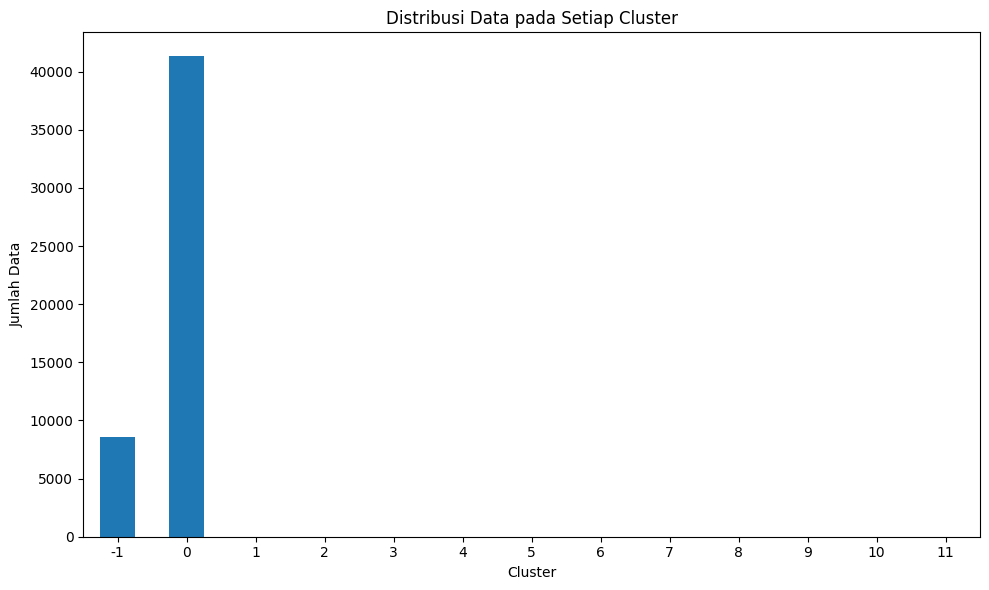

In [ ]:
plt.figure(figsize=(10, 6))

cluster_distribution.plot(kind='bar')

plt.title('Distribusi Data pada Setiap Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

4.3 Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score
non_noise_mask = labels != -1

X_eval = X_scaled.loc[non_noise_mask]
labels_eval = labels[non_noise_mask]

n_eval_clusters = len(set(labels_eval))

if n_eval_clusters >= 2:

    # Gunakan sampel agar perhitungan lebih ringan
    sample_size = min(5000, len(X_eval))

    sample_indices = np.random.RandomState(42).choice(
        len(X_eval),
        size=sample_size,
        replace=False
    )

    silhouette = silhouette_score(
        X_eval.iloc[sample_indices],
        labels_eval[sample_indices],
        metric='cosine'
    )

    print(
        'Silhouette Score (Cosine):',
        round(silhouette, 4)
    )

else:
    print(
        'Silhouette Score tidak dapat dihitung '
        'karena cluster kurang dari 2.'
    )

Silhouette Score (Cosine): -0.2623


4.4 Analisis Noise/Outlier

In [ ]:
noise_data = df[df['Cluster'] == -1]

print('Jumlah data yang menjadi noise:', len(noise_data))

print('\nPersentase noise:')
print(
    round(
        len(noise_data) / len(df) * 100,
        2
    ),
    '%'
)

Jumlah data yang menjadi noise: 8608

Persentase noise:
17.22 %


In [ ]:
noise_data.head()

,Person_ID,Age,Gender,Country,Occupation,Education_Level,Employment_Status,Monthly_Income_USD,Work_Hours_Per_Week,Remote_Work,...,Therapy_Attendance,Support_System,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score,Mental_Health_Status,AI_Wellness_Recommendation,Burnout_Risk,Cluster
6,7,33.0,Female,Nigeria,Police Officer,Diploma,Employed,9855.0,70,Hybrid,...,No,Average,5.0,51.0,7,41,Needs Attention,Take Regular Breaks,Moderate,-1
10,11,21.0,Male,Indonesia,Student,Bachelor,Student,558.0,60,No,...,Yes,Good,4.0,38.0,21,57,Needs Attention,Maintain Healthy Routine,Moderate,-1
22,23,52.0,Male,Japan,Teacher,High School,Self-Employed,11926.0,68,Yes,...,Yes,Good,2.0,40.0,3,48,Needs Attention,Seek Professional Support,Moderate,-1
30,31,41.0,Female,France,Sales Executive,PhD,Unemployed,9772.0,30,Hybrid,...,No,Good,10.0,55.0,20,47,Needs Attention,Practice Mindfulness,Moderate,-1
32,33,20.0,Other,Pakistan,Lawyer,High School,Self-Employed,5852.0,32,Hybrid,...,No,Poor,7.0,47.0,8,47,Needs Attention,Seek Professional Support,Moderate,-1


5. Reduksi Dimensi PCA

5.1 PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1', 'PC2'],
    index=df.index
)

pca_df['Cluster'] = labels

pca_df.head()

,PC1,PC2,Cluster
0,-5.189953,1.477253,0
1,-3.153151,1.676227,0
2,-1.395713,0.467338,0
3,3.269497,0.224071,0
4,1.266791,-1.994154,0


5.2 Visualisasi Hasil Klaster

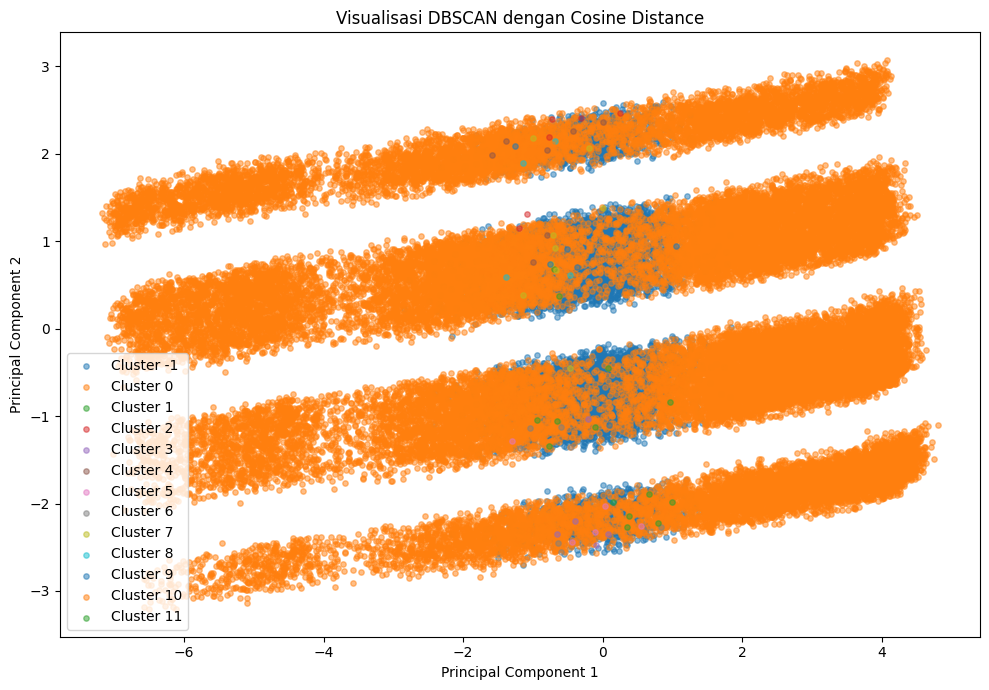

In [ ]:
plt.figure(figsize=(10, 7))

clusters = sorted(pca_df['Cluster'].unique())

for cluster in clusters:

    cluster_data = pca_df[
        pca_df['Cluster'] == cluster
    ]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}',
        alpha=0.5,
        s=15
    )

plt.title('Visualisasi DBSCAN dengan Cosine Distance')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()

plt.tight_layout()
plt.show()

6. Analisis

6.1 Profil Cluster

In [ ]:
cluster_profile = df.groupby(
    'Cluster'
)[numeric_columns].mean()

cluster_profile

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,Physical_Activity_Hours,Meditation_Minutes,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Coffee_Cups_Per_Day,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score
Cluster,,,,,,,,,,,,,,,,,,,,
-1,41.404881,6224.402705,46.167635,5.437632,5.498531,6.955611,43.067330,43.247595,56.783790,56.926580,4.881010,28.830601,8.139274,4.029139,2.969238,4.059944,5.563771,56.894462,14.986408,42.548908
0,41.455275,6258.622975,44.685018,5.512335,5.507873,7.006329,39.898169,40.046187,60.222559,59.902040,5.013546,30.280987,7.960438,3.983203,2.992114,3.979092,5.511185,59.980748,14.966943,39.705854
1,41.666667,3147.500000,48.833333,2.666667,2.500000,7.550000,46.500000,45.500000,56.000000,53.333333,4.266667,17.833333,12.483333,5.333333,1.316667,0.833333,8.666667,56.833333,13.166667,46.833333
2,38.000000,7288.800000,34.333333,7.666667,9.333333,4.466667,48.666667,49.000000,59.166667,49.166667,3.166667,41.500000,9.400000,1.516667,2.933333,2.833333,5.333333,56.333333,12.666667,46.666667
3,46.000000,2682.600000,55.600000,8.000000,6.000000,9.560000,46.200000,41.000000,57.600000,55.000000,3.780000,40.200000,10.420000,5.740000,1.040000,2.200000,2.400000,61.000000,15.200000,44.400000
4,33.714286,4394.666667,49.714286,6.714286,5.857143,4.728571,45.142857,47.000000,54.571429,54.000000,1.914286,39.714286,6.457143,4.442857,1.400000,0.714286,3.857143,50.285714,17.142857,49.285714
5,46.200000,5446.250000,54.800000,1.800000,6.000000,9.420000,40.200000,48.000000,56.400000,58.200000,2.540000,26.600000,4.580000,2.740000,1.500000,6.600000,7.200000,51.600000,13.600000,46.200000
6,52.714286,6799.500000,63.000000,7.571429,2.571429,8.985714,50.142857,41.285714,47.000000,48.285714,2.757143,10.285714,3.671429,3.500000,4.600000,6.857143,2.714286,48.857143,10.285714,38.142857
7,28.333333,5259.777778,53.222222,5.888889,1.333333,5.666667,47.888889,44.666667,53.875000,52.000000,3.755556,41.444444,7.533333,4.600000,4.311111,0.666667,8.444444,54.111111,22.666667,45.333333


In [ ]:
cluster_profile.round(2)

,Age,Monthly_Income_USD,Work_Hours_Per_Week,Job_Satisfaction,Work_Life_Balance,Sleep_Hours,Anxiety_Score,Depression_Score,Mood_Score,Emotional_Stability,Physical_Activity_Hours,Meditation_Minutes,Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Coffee_Cups_Per_Day,Life_Satisfaction,Productivity_Score,Absenteeism_Days,Burnout_Score
Cluster,,,,,,,,,,,,,,,,,,,,
-1,41.40,6224.40,46.17,5.44,5.50,6.96,43.07,43.25,56.78,56.93,4.88,28.83,8.14,4.03,2.97,4.06,5.56,56.89,14.99,42.55
0,41.46,6258.62,44.69,5.51,5.51,7.01,39.90,40.05,60.22,59.90,5.01,30.28,7.96,3.98,2.99,3.98,5.51,59.98,14.97,39.71
1,41.67,3147.50,48.83,2.67,2.50,7.55,46.50,45.50,56.00,53.33,4.27,17.83,12.48,5.33,1.32,0.83,8.67,56.83,13.17,46.83
2,38.00,7288.80,34.33,7.67,9.33,4.47,48.67,49.00,59.17,49.17,3.17,41.50,9.40,1.52,2.93,2.83,5.33,56.33,12.67,46.67
3,46.00,2682.60,55.60,8.00,6.00,9.56,46.20,41.00,57.60,55.00,3.78,40.20,10.42,5.74,1.04,2.20,2.40,61.00,15.20,44.40
4,33.71,4394.67,49.71,6.71,5.86,4.73,45.14,47.00,54.57,54.00,1.91,39.71,6.46,4.44,1.40,0.71,3.86,50.29,17.14,49.29
5,46.20,5446.25,54.80,1.80,6.00,9.42,40.20,48.00,56.40,58.20,2.54,26.60,4.58,2.74,1.50,6.60,7.20,51.60,13.60,46.20
6,52.71,6799.50,63.00,7.57,2.57,8.99,50.14,41.29,47.00,48.29,2.76,10.29,3.67,3.50,4.60,6.86,2.71,48.86,10.29,38.14
7,28.33,5259.78,53.22,5.89,1.33,5.67,47.89,44.67,53.88,52.00,3.76,41.44,7.53,4.60,4.31,0.67,8.44,54.11,22.67,45.33


6.2 Perbandingan Cluster dengan Burnout Risk

In [ ]:
cluster_burnout = pd.crosstab(
    df['Cluster'],
    df['Burnout_Risk']
)

cluster_burnout

Burnout_Risk,High,Low,Moderate
Cluster,,,
-1,50,3321,5237
0,9800,22028,9495
1,0,1,5
2,0,1,5
3,0,0,5
4,1,0,6
5,0,2,3
6,0,6,1
7,0,1,8


6.3 Visualisasi Perbandingan Antar

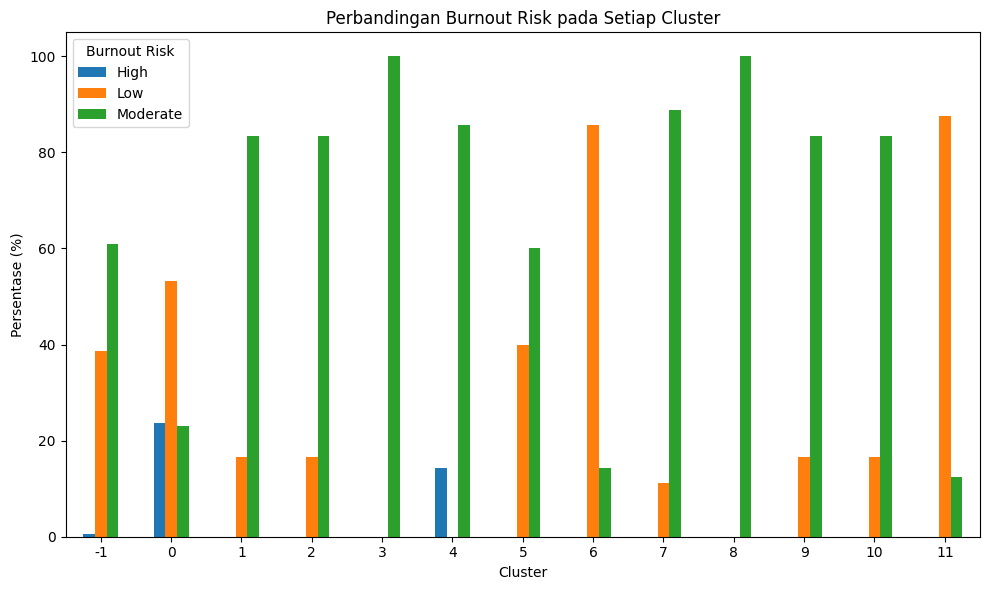

In [ ]:
cluster_burnout_percentage = cluster_burnout.div(cluster_burnout.sum(axis=1), axis=0) * 100

cluster_burnout_percentage.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title(
    'Perbandingan Burnout Risk pada Setiap Cluster'
)

plt.xlabel('Cluster')
plt.ylabel('Persentase (%)')

plt.xticks(rotation=0)
plt.legend(title='Burnout Risk')

plt.tight_layout()
plt.show()

6.4 Ringkasan Model

In [ ]:
print('\nParameter:')
print('Metric       : Cosine')
print('eps          :', eps_final)
print('min_samples  :', min_samples_final)

print('\nHasil Clustering:')
print('Jumlah data  :', len(df))
print('Jumlah cluster:', n_clusters)
print('Jumlah noise :', n_noise)

print(
    'Persentase noise:',
    round(n_noise / len(df) * 100, 2),
    '%'
)

if n_eval_clusters >= 2:
    print(
        'Silhouette Score:',
        round(silhouette, 4)
    )

print('\nDistribusi Cluster:')
display(
    df['Cluster']
    .value_counts()
    .sort_index()
    .to_frame('Jumlah Data')
)


Parameter:
Metric       : Cosine
eps          : 0.3
min_samples  : 10

Hasil Clustering:
Jumlah data  : 50000
Jumlah cluster: 12
Jumlah noise : 8608
Persentase noise: 17.22 %
Silhouette Score: -0.2623

Distribusi Cluster:


,Jumlah Data
Cluster,
-1,8608
0,41323
1,6
2,6
3,5
4,7
5,5
6,7
7,9
